# 05. Visualization

This notebook visualizes the processed data and graph structures, including POI distributions, land use, and metapaths.

In [1]:
"""
# Colab setup (optional)
!git clone https://github.com/c2g-dev/city2graph-case-study.git

import os
REPO_DIR = "/content/city2graph-case-study"
os.chdir(REPO_DIR)

# delete data directory
!rm -rf /content/city2graph-case-study/data

# download data zip from Zenodo and unzip into data/
!wget -O /content/city2graph-case-study/data.zip https://zenodo.org/records/18396286/files/data.zip?download=1
!unzip -o /content/city2graph-case-study/data.zip -d /content/city2graph-case-study/

!pip install torch_geometric
!pip install city2graph
!pip install contextily

os.chdir(REPO_DIR + "/notebooks")
"""

'\n# Colab setup (optional)\n!git clone https://github.com/c2g-dev/city2graph-case-study.git\n\nimport os\nREPO_DIR = "/content/city2graph-case-study"\nos.chdir(REPO_DIR)\n\n# delete data directory\n!rm -rf /content/city2graph-case-study/data\n\n# download data zip from Zenodo and unzip into data/\n!wget -O /content/city2graph-case-study/data.zip https://zenodo.org/records/18396286/files/data.zip?download=1\n!unzip -o /content/city2graph-case-study/data.zip -d /content/city2graph-case-study/\n\n!pip install torch_geometric\n!pip install city2graph\n!pip install contextily\n\nos.chdir(REPO_DIR + "/notebooks")\n'

In [2]:
import os

import geopandas as gpd
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
import pandas as pd
import matplotlib.pyplot as plt
import contextily as ctx

from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.colors import ListedColormap

# Set plot style
plt.style.use('default')

# Paths
DATA_DIR = "../data"
PROCESSED_DIR = os.path.join(DATA_DIR, "processed")
RAW_DIR = os.path.join(DATA_DIR, "raw")
OUTPUT_DIR = os.path.join(DATA_DIR, "outputs")

FEATURES_DIR = os.path.join(PROCESSED_DIR, "features")
GRAPHS_DIR = os.path.join(PROCESSED_DIR, "graphs")

FIGURES_DIR = os.path.join(OUTPUT_DIR, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

In [3]:
# OA node feature columns (fixed list for this case study)
OA_FEATURE_COLS = [
    "arts_culture",
    "automotive_facility",
    "consumer_service",
    "corporate_service",
    "education",
    "entertainment",
    "food_beverage",
    "healthcare",
    "hotel_lodging",
    "industrial_service",
    "park",
    "public_service",
    "religion",
    "retail",
    "sports_fitness",
    "transportation_facility"
]

## 1. POI Visualization
Visualize POI density/categories across OAs.

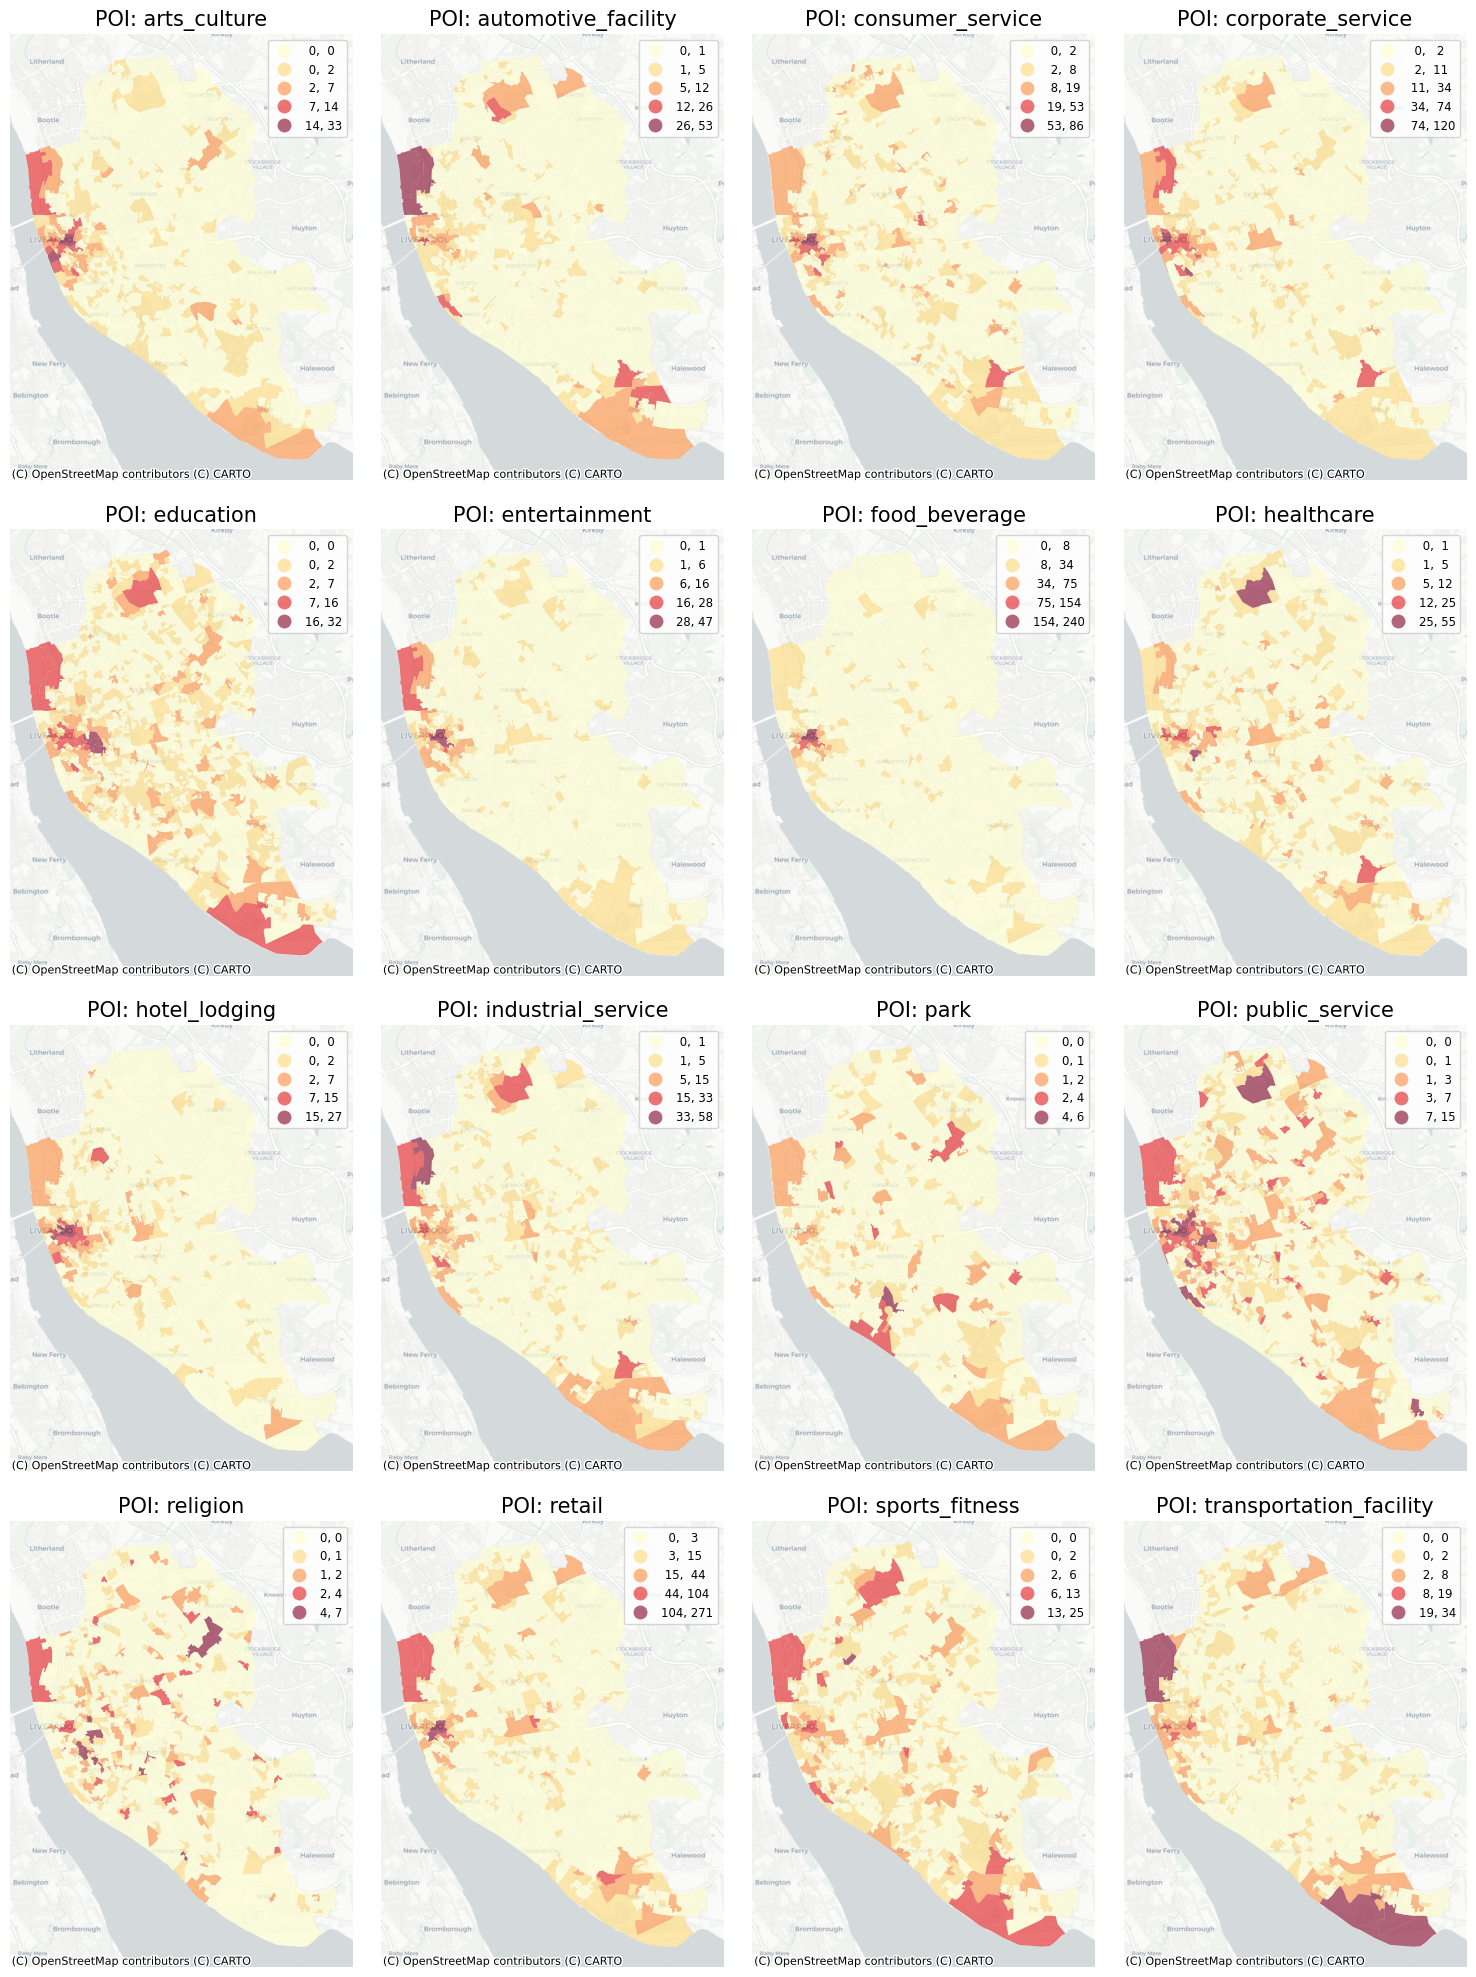

In [4]:
# Load OA features
oa_features_path = os.path.join(FEATURES_DIR, "oa_with_features.gpkg")
oa_with_features = gpd.read_file(oa_features_path)

# Filter for numeric columns only to avoid TypeError in plotting
categories = [c for c in oa_with_features.columns if c in OA_FEATURE_COLS and pd.api.types.is_numeric_dtype(oa_with_features[c])]
n_cols = 4
n_rows = (len(categories) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categories):
    oa_with_features.to_crs("EPSG:3857").plot(
        column=col,
        ax=axes[i],
        scheme='NaturalBreaks',
        k=5,
        legend=True, 
        cmap='YlOrRd',
        alpha=0.6,
        linewidth=0,
        legend_kwds={'loc': 'upper right', 'fmt': "{:.0f}", 'fontsize': 'small'}
    )

    # Add the basemap to each axis
    ctx.add_basemap(axes[i], source=ctx.providers.CartoDB.Positron)
    
    axes[i].set_title(f'POI: {col}', fontsize=15)
    axes[i].set_axis_off()

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "poi.jpg"), bbox_inches='tight', dpi=200)
plt.show()

## 2. Land Use Visualization
Visualize land use classes with a custom color palette.

In [5]:
# Load Land Use Data
land_use_path = "../data/raw/overture/land_uses.gpkg"
land_uses = gpd.read_file(land_use_path)

# Define Category Mapping (Class -> Functional Group)
LAND_USE_MAPPING = {
    'residential': ['residential', 'garages'],
    'commercial': ['commercial', 'retail', 'plaza'],
    'industrial': ['industrial', 'works', 'brownfield', 'construction'],
    'public_services': ['school', 'university', 'college', 'hospital', 'clinic', 'doctors', 'religious', 'military', 'base', 'cemetery', 'grave_yard'],
    'green_space': ['park', 'grass', 'garden', 'meadow', 'nature_reserve', 'village_green', 'green', 'greenfield', 'flowerbed', 'orchard', 'allotments', 'recreation_ground', 'playground', 'pitch', 'stadium', 'golf_course', 'fairway', 'tee', 'bunker', 'rough', 'water_hazard'],
    'transportation': ['railway', 'track', 'pedestrian'],
    'agricultural': ['farmland', 'farmyard'],
    'other': []
}

# HELPER: REVERSE LOOKUP
def get_reverse_mapping(mapping_dict):
    """
    Generates a dictionary where Keys = Specific Types (e.g. 'residential')
    and Values = Category (e.g. 'residential').
    """
    reverse_map = {}
    duplicates = []
    for category, items in mapping_dict.items():
        for item in items:
            if item in reverse_map:
                duplicates.append(f"{item} (found in {reverse_map[item]} and {category})")
            reverse_map[item] = category
    if duplicates:
        print(f"Warning: Found duplicates in mapping: {duplicates}")
    return reverse_map

LAND_USE_TO_CLASS = get_reverse_mapping(LAND_USE_MAPPING)

def map_land_use_class(cls):
    """Maps a detailed land use class to a broader functional class."""
    if pd.isna(cls):
        return 'other'
    return LAND_USE_TO_CLASS.get(cls, 'other')

# Apply the mapping
land_uses['land_use_class'] = land_uses['class'].apply(map_land_use_class)

# Inspect mapped classes
print(land_uses['land_use_class'].value_counts())


land_use_class
green_space        4184
residential         462
industrial          292
public_services     254
transportation      222
commercial          212
agricultural         39
Name: count, dtype: int64


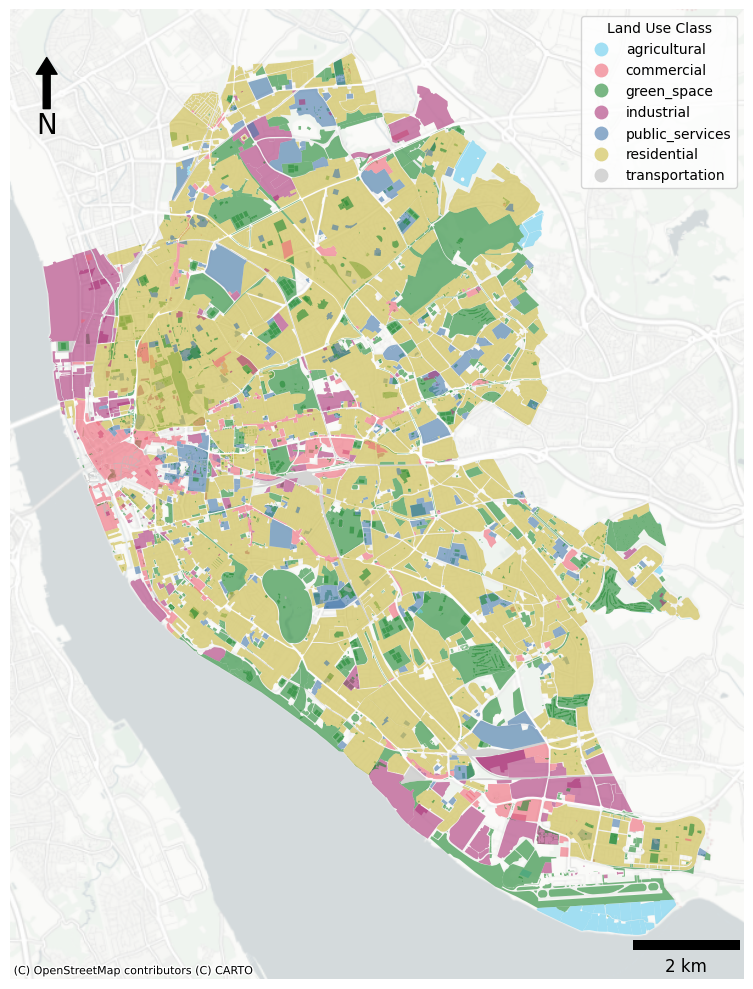

In [6]:
# Paul Tol 'bright' qualitative scheme: colour-blind safe (reviewer request)
import tol_colors as tc
_tol_bright = tc.bright

land_use_colors = {
    'green_space':     _tol_bright.green,
    'residential':     _tol_bright.yellow,
    'industrial':      _tol_bright.purple,
    'public_services': _tol_bright.blue,
    'transportation':  _tol_bright.grey,
    'commercial':      _tol_bright.red,
    'agricultural':    _tol_bright.cyan,
}

# Ensure colours are mapped to the sorted unique categories present in the data
categories = sorted(land_uses['land_use_class'].unique())
cmap = ListedColormap([land_use_colors.get(cat, '#000000') for cat in categories])

fig, ax = plt.subplots(figsize=(16, 10))

# Plot in the original CRS (EPSG:27700, British National Grid) — no reprojection
land_uses.plot(
    column='land_use_class',
    ax=ax,
    legend=True,
    categorical=True,
    cmap=cmap,
    alpha=0.6,
    legend_kwds={'loc': 'upper right', 'title': 'Land Use Class', 'frameon': True}
)

# Add basemap, telling contextily the data CRS so it reprojects the tiles instead
ctx.add_basemap(ax, crs=land_uses.crs, source=ctx.providers.CartoDB.PositronNoLabels)

# Add scale bar (dx=1 is correct because 27700 is in metres)
scalebar = ScaleBar(1, units="m", location="lower right", frameon=False,
                    font_properties={'size': 12})
ax.add_artist(scalebar)

# Add north mark
x, y, arrow_length = 0.05, 0.95, 0.07
ax.annotate('N', xy=(x, y), xytext=(x, y - arrow_length),
            arrowprops=dict(facecolor='black', width=5, headwidth=15),
            ha='center', va='center', fontsize=20,
            xycoords='axes fraction')

ax.set_axis_off()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "land_use.jpg"), bbox_inches='tight', pad_inches=0, dpi=200)
plt.show()

## 3. Metapath Visualization
Visualize graph metapaths with edge colors representing travel time.

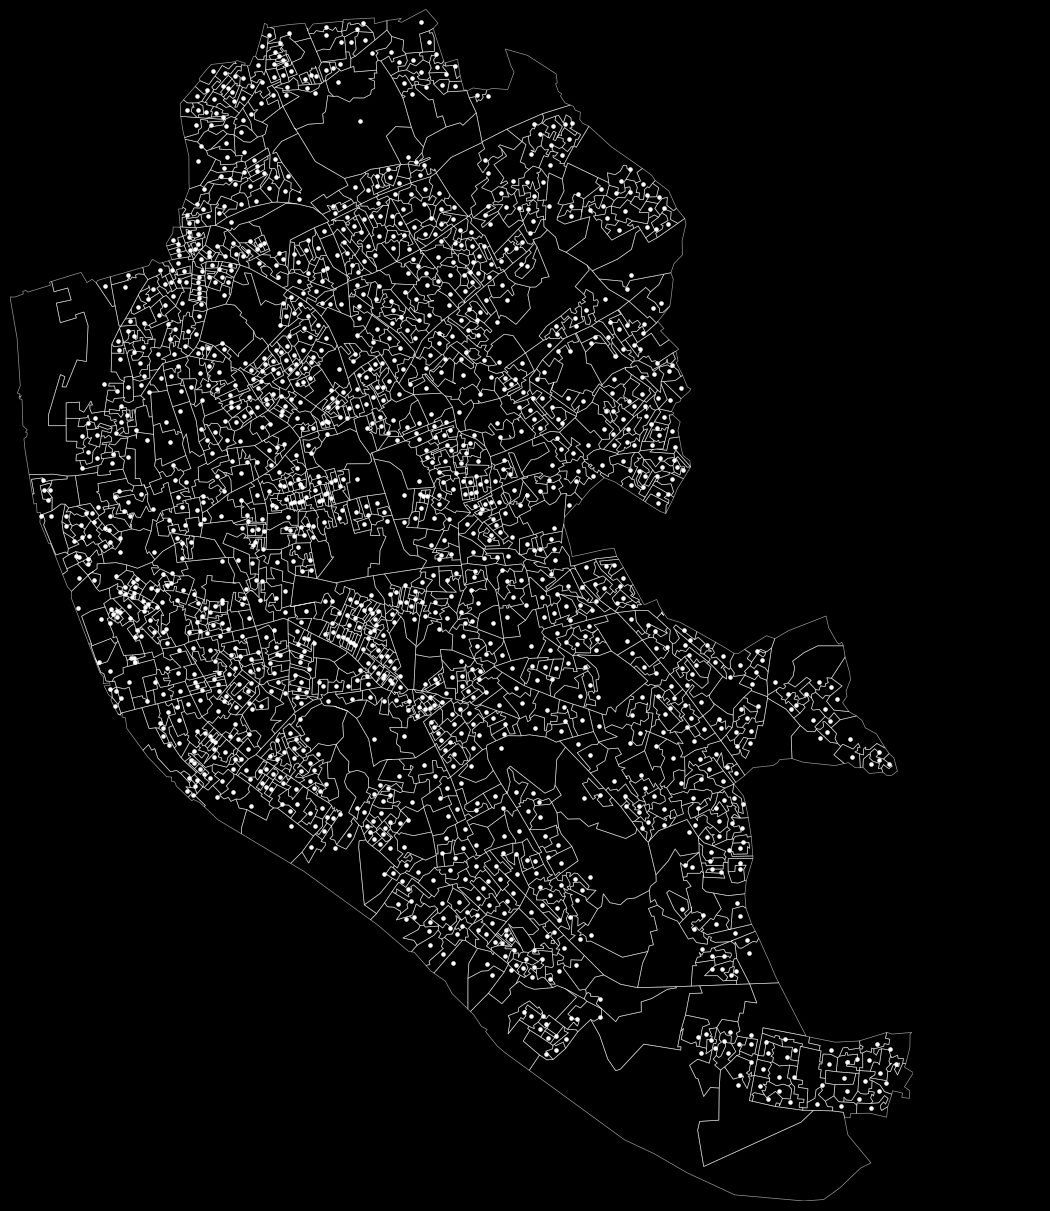

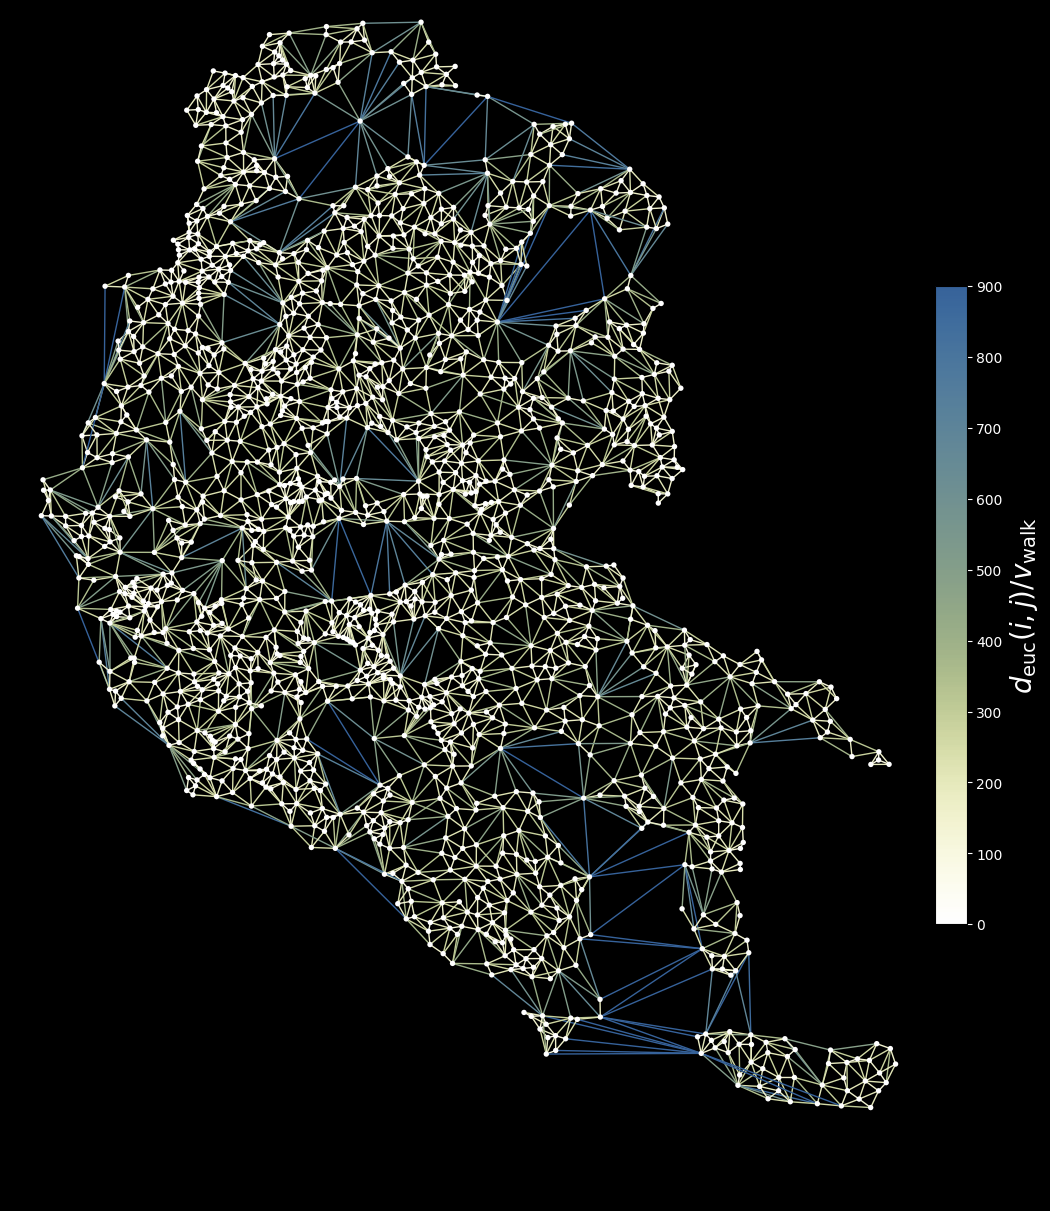

In [7]:
import os
import numpy as np
import torch
import city2graph as c2g
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import geopandas as gpd
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from matplotlib.lines import Line2D

from cmcrameri import cm as cmc

# Load Graph Data (Hetero Multi)
# (Assuming GRAPHS_DIR and other paths are defined in previous cells or here)
graph_path = os.path.join(GRAPHS_DIR, "hetero_multi.pt")
data = torch.load(graph_path, weights_only=False)

hetero_nodes_multi, hetero_edges_multi = c2g.pyg_to_gdf(data)

# Plot configuration
edge_types = [('oa', 'contig', 'oa'), ('oa', '15_min_walk', 'oa'), ('oa', '15_min_multi', 'oa')]
edge_lws = [1, 0.5, 0.25] #[1, 0.1, 0.05]
vmin, vmax = 0, 900
norm = colors.Normalize(vmin=vmin, vmax=vmax)

base = cmc.davos.reversed()

def truncate(c, lo=0.0, hi=0.72, n=256):
    return LinearSegmentedColormap.from_list("trunc", c(np.linspace(lo, hi, n)))

cmap = truncate(base) #cm.viridis

# Keep all split outputs at identical image dimensions
SPLIT_FIG_SIZE = (12, 12)
SPLIT_SAVE_KW = {"facecolor": "black", "dpi": 300, "bbox_inches": "tight", "pad_inches": 0}

# Prepare OA data
fpath = os.path.join(FEATURES_DIR, "oa_with_features.gpkg")
oa_polygons = gpd.read_file(fpath)
minx, miny, maxx, maxy = oa_polygons.total_bounds

# Process weighted centroids
node_gdf = oa_polygons.copy()
node_gdf.set_index("OA21CD", inplace=True)
node_gdf['geometry'] = gpd.GeoSeries.from_wkt(node_gdf['pop_weighted_centroid'])

BACKGROUND_COLOR = 'black'
TRANSPARENT = (1, 1, 1, 0)
CBAR_LABEL = r'$d_{\text{euc}}(i,j) / v_{\text{walk}}$'

def add_matched_colorbar(fig, ax, text_color='white', black_bar=False):
    # Keep colorbar geometry identical; optionally paint the bar itself black for OA.
    if black_bar:
        sm = cm.ScalarMappable(cmap=ListedColormap([BACKGROUND_COLOR]), norm=norm)
    else:
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.03, pad=0.02)
    cbar.set_label(CBAR_LABEL, color=text_color, fontsize=20)
    cbar.ax.yaxis.set_tick_params(color=text_color, labelcolor=text_color)
    if black_bar:
        cbar.ax.set_facecolor(BACKGROUND_COLOR)
        cbar.outline.set_edgecolor(BACKGROUND_COLOR)
    return cbar

def plot_transparent_reference_graph(ax):
    for edge_type, lw, markersize in zip(edge_types, edge_lws, [15, 3, 3]):
        df = hetero_edges_multi[edge_type]
        c2g.plot_graph(
            nodes=node_gdf,
            edges={edge_type: df},
            ax=ax,
            markersize=markersize,
            edge_linewidth={edge_type: lw},
            node_color=TRANSPARENT,
            edge_color={edge_type: [TRANSPARENT] * len(df)},
            node_alpha=0,
            edge_alpha=0,
            legend_position=None,
            bgcolor=BACKGROUND_COLOR,
            subplots=False
        )

# --- Figure 1A: OA polygons + weighted centroids ---
fig, ax = plt.subplots(1, 1, figsize=SPLIT_FIG_SIZE, facecolor='black', constrained_layout=True)
ax.set_facecolor('black')
plot_transparent_reference_graph(ax)
oa_polygons.plot(facecolor='none', edgecolor='white', linewidth=0.5, ax=ax, alpha=0.6)
node_gdf.plot(ax=ax, color='white', markersize=5, alpha=1)
add_matched_colorbar(fig, ax, text_color='black', black_bar=True)
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.set_axis_off()
plt.savefig(os.path.join(FIGURES_DIR, "liverpool_contig_oa.jpg"), **SPLIT_SAVE_KW)
plt.show()

# --- Figure 1B: Contiguity edges ---
fig, ax = plt.subplots(1, 1, figsize=SPLIT_FIG_SIZE, facecolor='black', constrained_layout=True)
ax.set_facecolor('black')
edge_type = edge_types[0]  # ('oa', 'contig', 'oa')
lw = edge_lws[0]
df = hetero_edges_multi[edge_type]
edge_colors = [cmap(norm(val)) for val in df["travel_time_sec"]]

# Plot transparent OA polygons to anchor extent while remaining invisible
oa_polygons.plot(facecolor='none', edgecolor=TRANSPARENT, linewidth=0.5, ax=ax, alpha=0)

c2g.plot_graph(
    nodes={"oa": node_gdf},
    edges={edge_type: df},
    ax=ax,
    markersize=15,
    edge_linewidth={edge_type: lw},
    node_color="white",
    edge_color={edge_type: edge_colors},
    node_alpha=1,
    edge_alpha=1,
    legend_position=None,
    bgcolor=BACKGROUND_COLOR,
    subplots=False
)

add_matched_colorbar(fig, ax, text_color='white')
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.set_axis_off()
plt.savefig(os.path.join(FIGURES_DIR, "liverpool_contig_edges.jpg"), **SPLIT_SAVE_KW)
plt.show()

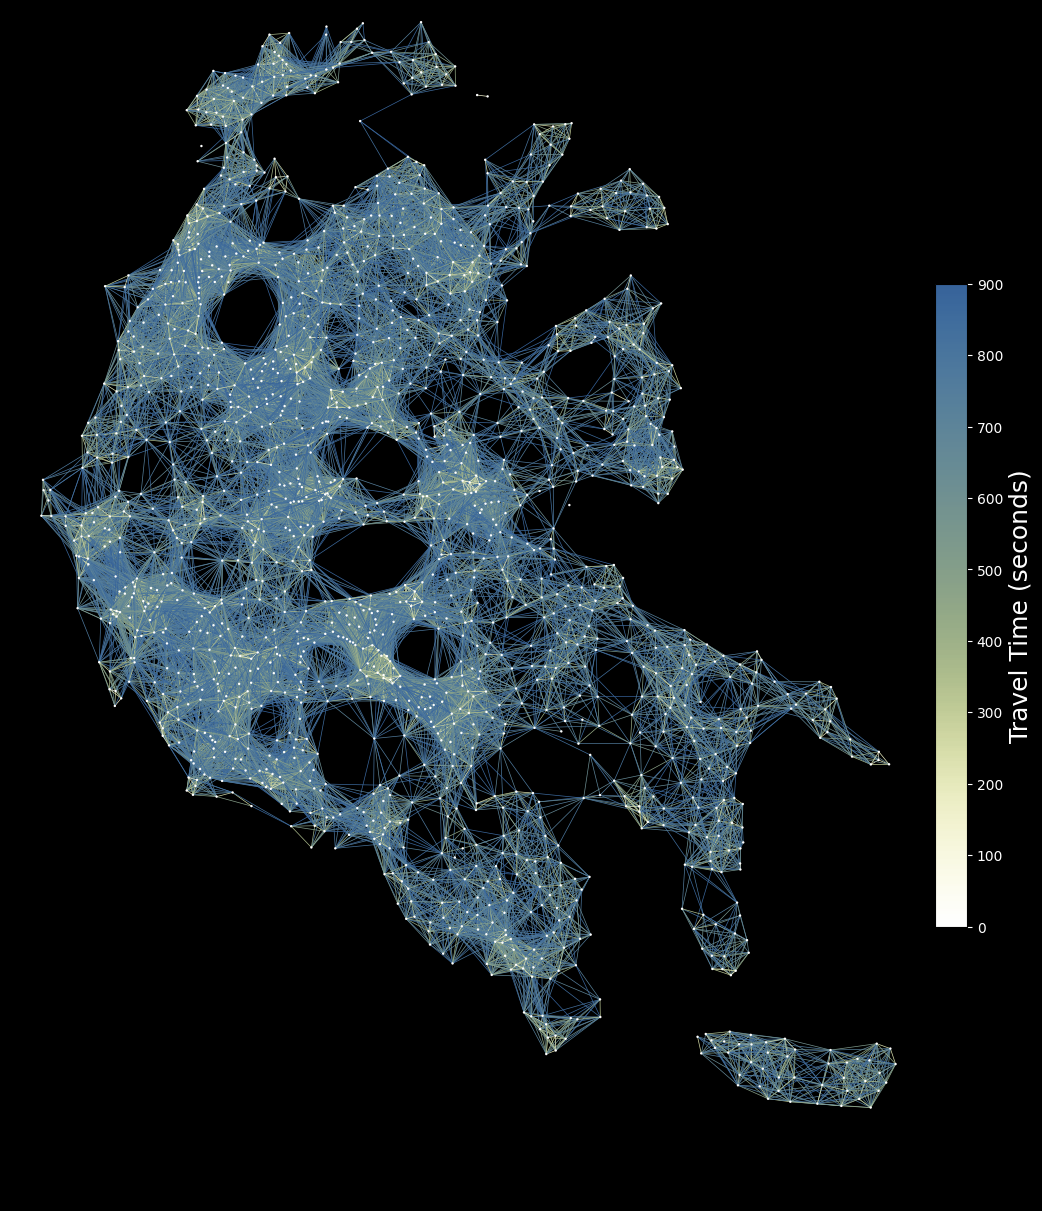

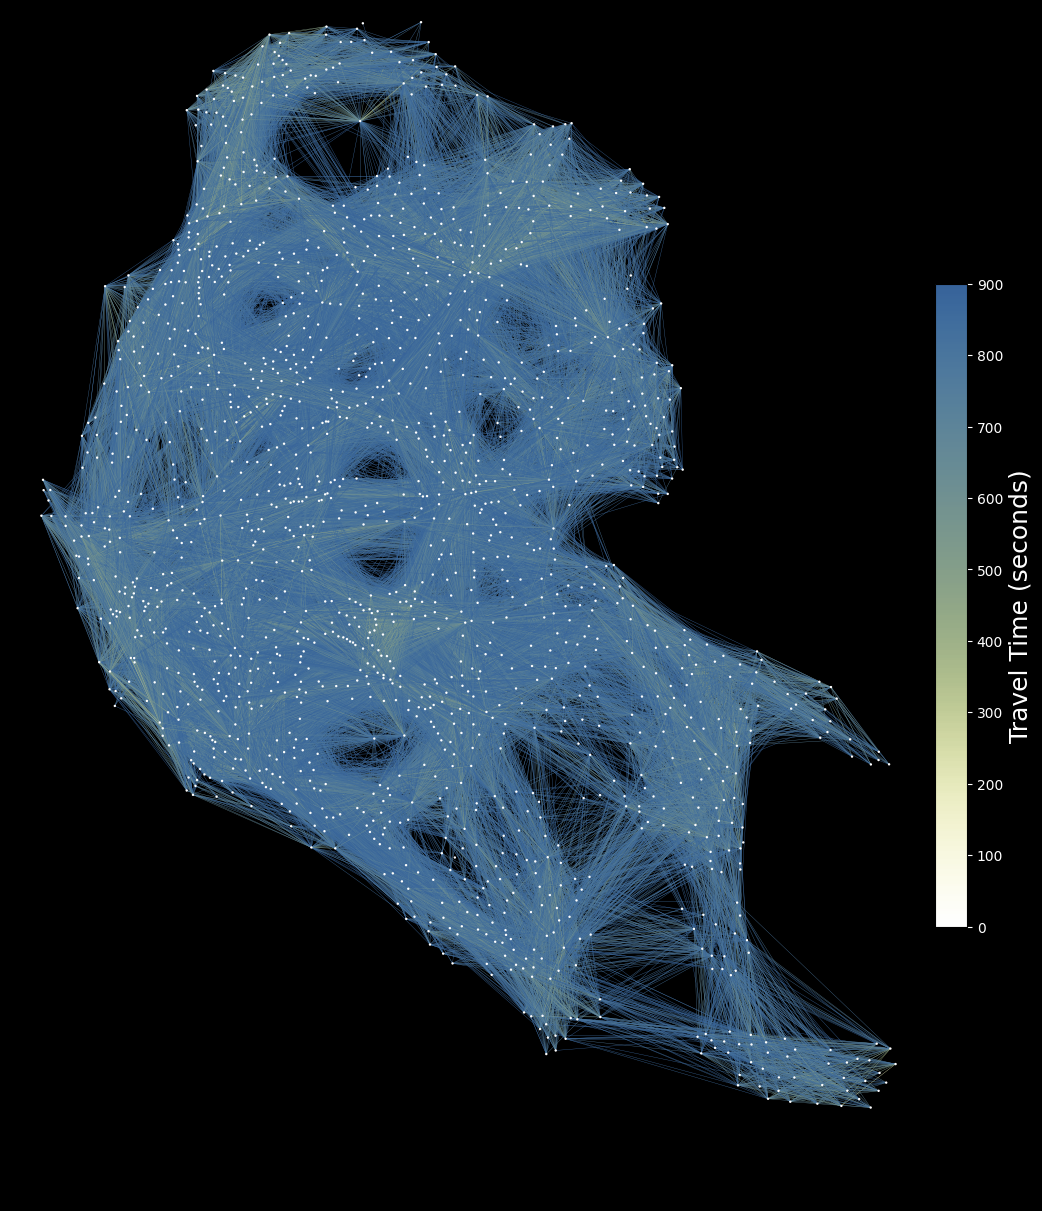

In [8]:
# --- Figure 2: Metapaths (split into one figure per relation) ---
metapath_configs = [
    (1, "liverpool_metapaths_walk.jpg"),
    (2, "liverpool_metapaths_multi.jpg"),
]

for idx, out_name in metapath_configs:
    fig, ax = plt.subplots(1, 1, figsize=SPLIT_FIG_SIZE, facecolor='black', constrained_layout=True)
    ax.set_facecolor('black')

    edge_type = edge_types[idx]
    lw = edge_lws[idx]
    df = hetero_edges_multi[edge_type]
    edge_colors = [cmap(norm(val)) for val in df["travel_time_sec"]]

    # Background OAs
    oa_polygons.plot(facecolor='none', edgecolor='white', linewidth=0.05, ax=ax, alpha=0)

    c2g.plot_graph(
        nodes={"oa": node_gdf},
        edges={edge_type: df},
        ax=ax,
        markersize=3,
        edge_linewidth={edge_type: lw},
        node_color="white",
        edge_color={edge_type: edge_colors},
        node_alpha=1,
        edge_alpha=1,
        legend_position=None,
        bgcolor=BACKGROUND_COLOR,
        subplots=False
    )

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.03, pad=0.02)

    label = "Travel Time (seconds)"
    cbar.set_label(label, color='white', fontsize=18)
    cbar.ax.yaxis.set_tick_params(color='white', labelcolor='white')

    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    ax.set_axis_off()

    plt.savefig(os.path.join(FIGURES_DIR, out_name), **SPLIT_SAVE_KW)
    plt.show()

## 4. Edge Relation Descriptive Statistics
Create a table of descriptive statistics for each edge relation.

In [9]:
# Build descriptive stats for each relation in the hetero graph
# NOTE (city2graph >= 0.4.0): graphs are undirected and edge_index stores BOTH
# directions, but pyg_to_gdf() returns ONE row per undirected pair. The counts
# below are therefore reported per undirected edge (pair), not per direction.
TABLES_DIR = os.path.join(OUTPUT_DIR, "tables")
os.makedirs(TABLES_DIR, exist_ok=True)

desired_edge_types = [
    ("oa", "is_nearby", "street_connector"),
    ("street_connector", "is_connected_to", "street_connector"),
    ("bus_station", "is_nearby", "street_connector"),
    ("bus_station", "is_next_to", "bus_station"),
    ("oa", "contig", "oa"),
    ("oa", "15_min_walk", "oa"),
    ("oa", "15_min_multi", "oa"),
]

relation_rows = []
for edge_type in desired_edge_types:
    if edge_type not in hetero_edges_multi:
        continue
    df = hetero_edges_multi[edge_type]
    # Keep numeric columns only (e.g., travel_time_sec)
    numeric_df = df.select_dtypes(include="number")
    if numeric_df.empty:
        continue
    stats = numeric_df.agg(["count", "min", "mean", "max", "std"]).T
    stats["count"] = stats["count"].astype(int)
    stats[["min", "mean", "max", "std"]] = stats[["min", "mean", "max", "std"]].round(2)
    stats = stats[["count", "min", "mean", "max", "std"]]
    stats.insert(0, "edge_type", str(edge_type))
    relation_rows.append(stats.reset_index().rename(columns={"index": "metric"}))

edge_relation_stats = pd.concat(relation_rows, ignore_index=True)
display(edge_relation_stats)

edge_relation_stats.to_csv(
    os.path.join(TABLES_DIR, "edge_relation_descriptive_stats.csv"),
    index=False
)

,metric,edge_type,count,min,mean,max,std
0,travel_time_sec,"('oa', 'is_nearby', 'street_connector')",1624,0.61,23.81,113.46,16.74
1,travel_time_sec,"('street_connector', 'is_connected_to', 'stree...",65386,0.01,32.76,1081.63,38.96
2,travel_time_sec,"('bus_station', 'is_nearby', 'street_connector')",1724,0.65,15.76,99.85,10.10
3,travel_time_sec,"('bus_station', 'is_next_to', 'bus_station')",2290,10.00,92.65,1980.00,93.48
4,travel_time_sec,"('oa', 'contig', 'oa')",4782,23.33,225.89,1699.17,151.71
5,travel_time_sec,"('oa', '15_min_walk', 'oa')",28265,30.55,620.23,899.98,195.94
6,travel_time_sec,"('oa', '15_min_multi', 'oa')",69403,232.28,766.26,900.00,100.14
